In [6]:
import pandas as pd
import numpy as np
import random
!pip install faker
from faker import Faker
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 77.9 MB/s eta 0:00:00


In [7]:
fake = Faker()

countries = ['India', 'USA', 'UK', 'Brazil', 'Germany', 'France', 'Italy', 'China']

data = []

for i in range(500):
    date = fake.date_between(start_date='-2y', end_date='today')
    country = random.choice(countries)

    confirmed = random.randint(1000, 100000)
    deaths = random.randint(10, 5000)
    recovered = random.randint(500, confirmed)

    active = confirmed - deaths - recovered

    data.append([date, country, confirmed, deaths, recovered, active])

df = pd.DataFrame(data, columns=[
    'Date', 'Country', 'Confirmed', 'Deaths', 'Recovered', 'Active'
])

df.head()

,Date,Country,Confirmed,Deaths,Recovered,Active
0,2025-10-03,China,43022,3459,30279,9284
1,2026-01-07,India,19910,1788,9303,8819
2,2025-09-23,France,27310,874,18498,7938
3,2025-04-19,Germany,89597,1436,21230,66931
4,2024-09-14,Brazil,53898,2711,18890,32297


In [8]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 381 to 53
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       500 non-null    datetime64[ns]
 1   Country    500 non-null    object        
 2   Confirmed  500 non-null    int64         
 3   Deaths     500 non-null    int64         
 4   Recovered  500 non-null    int64         
 5   Active     500 non-null    int64         
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 27.3+ KB


In [9]:
print("Total Confirmed:", df['Confirmed'].sum())
print("Total Deaths:", df['Deaths'].sum())
print("Total Recovered:", df['Recovered'].sum())

Total Confirmed: 26242586
Total Deaths: 1272088
Total Recovered: 12893371


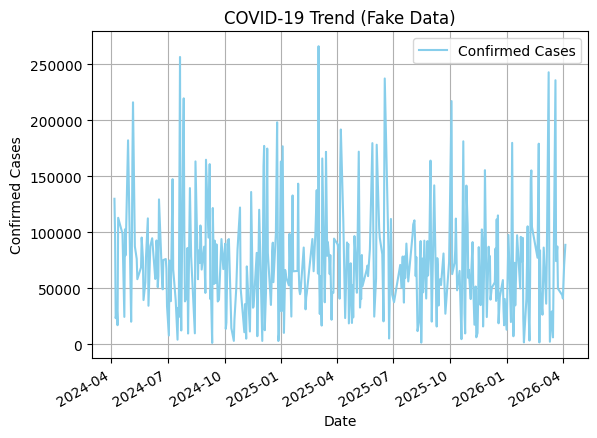

In [14]:
trend = df.groupby('Date').sum()

plt.figure()
trend['Confirmed'].plot(color='skyblue', label='Confirmed Cases')
plt.title("COVID-19 Trend (Fake Data)")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.legend()
plt.grid(True)
plt.show()

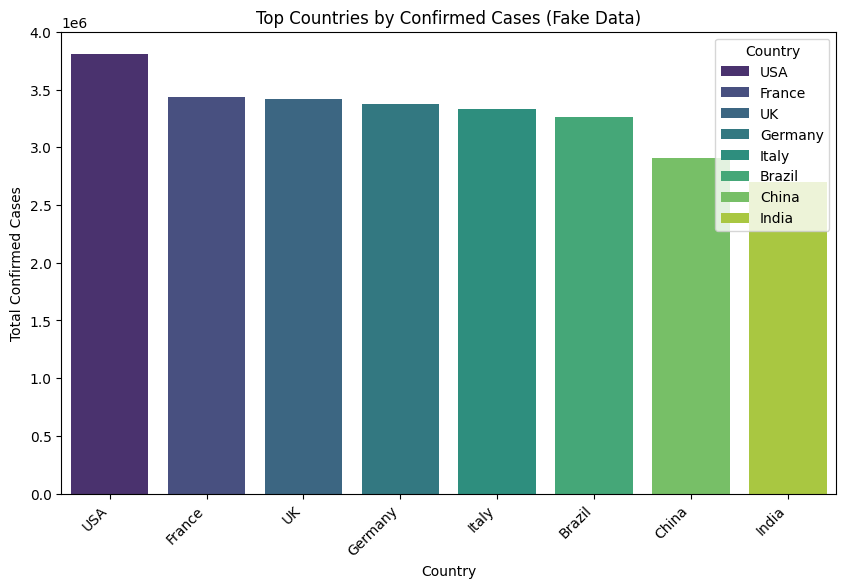

In [17]:
top_countries = df.groupby('Country')['Confirmed'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.index, y=top_countries.values, hue=top_countries.index, palette='viridis', legend=True)
plt.title("Top Countries by Confirmed Cases (Fake Data)")
plt.xlabel("Country")
plt.ylabel("Total Confirmed Cases")
plt.xticks(rotation=45, ha='right')
plt.show()

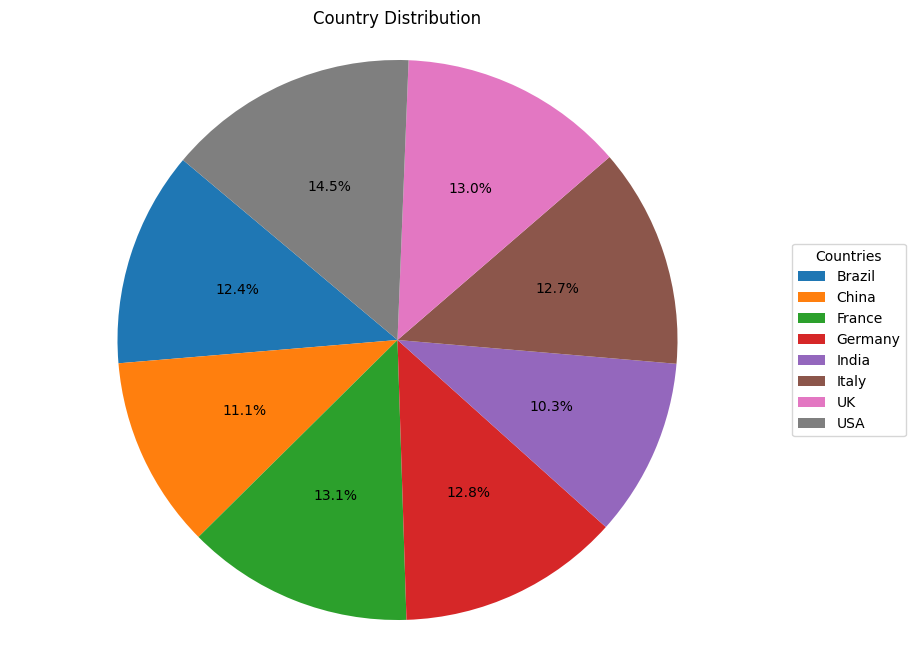

In [19]:
latest = df.groupby('Country')[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum()

plt.figure(figsize=(10, 8))
plt.pie(latest['Confirmed'], autopct='%1.1f%%', startangle=140)
plt.title("Country Distribution")
plt.legend(latest.index, title="Countries", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.axis('equal')
plt.show()

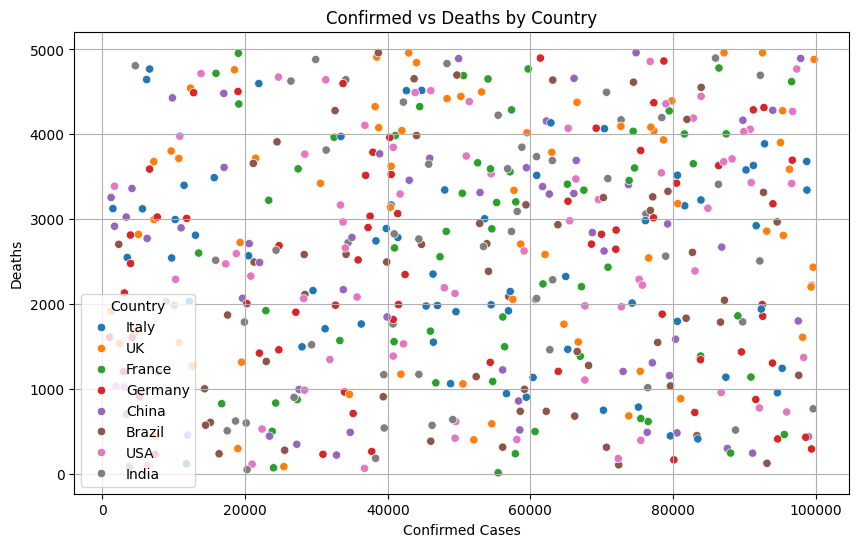

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Confirmed'], y=df['Deaths'], hue=df['Country'], palette='tab10')
plt.title("Confirmed vs Deaths by Country")
plt.xlabel("Confirmed Cases")
plt.ylabel("Deaths")
plt.legend(title="Country")
plt.grid(True)
plt.show()

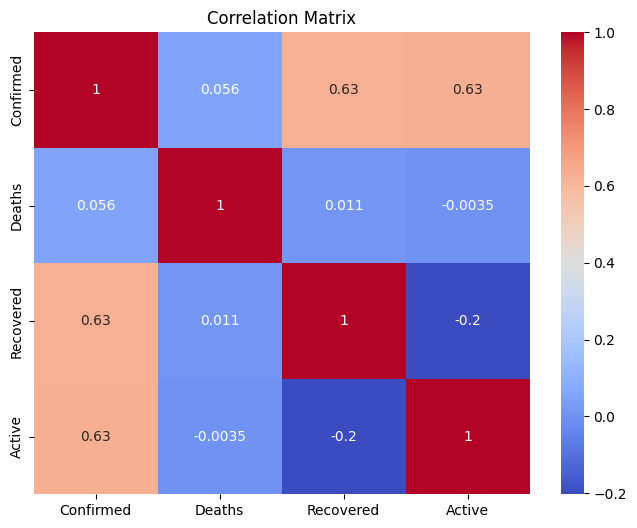

In [26]:
corr = df[['Confirmed', 'Deaths', 'Recovered', 'Active']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', cbar=True)
plt.title("Correlation Matrix")
plt.show()

In [27]:
fig = px.line(trend, x=trend.index, y='Confirmed', title='COVID Trend (Fake Data)')
fig.show()